In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [3]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][:] = vars[sv]
                    

In [4]:
tol = 1e-32

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

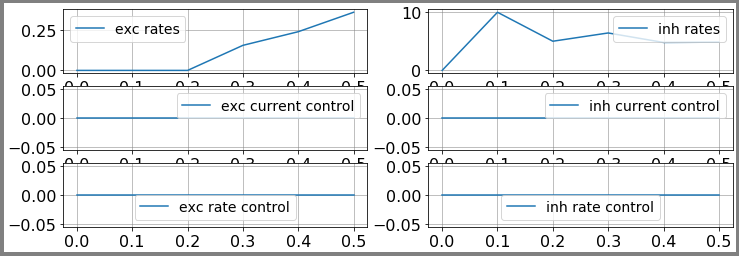

In [423]:
aln = RateModel()

aln.params['duration'] = 0.5
aln.params.dt = 0.1
control0 = aln.getZeroControl()

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

aln.params.cie = 1.
aln.params.Jie_max = 1.
aln.params.tau_se = 1.
aln.params.tau_si = 1.
aln.params.C = 1.
aln.params.gL = 1.
aln.params.Ke = 1000.
aln.params.Ki = 1000.
aln.params.c_gl *= 5.

plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

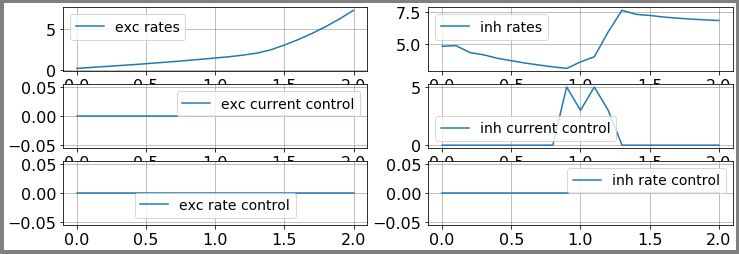

no delay : 
exc rates :  [0.23932845 0.35948714 0.46100716 0.5764934  0.69180858 0.81512182
 0.94285241 1.07678837 1.21604506 1.36092763 1.51120171 1.66688564
 1.86357619 2.1030359  2.50329491 3.09991336 3.76488685 4.51971656
 5.36425793 6.3052618  7.34834039]
inh rates :  [4.80834722 4.85953963 4.31453139 4.13173711 3.85478758 3.66560745
 3.47758461 3.3208701  3.17841699 3.05334852 3.56628725 3.97917517
 5.9510796  7.66839912 7.3460595  7.25642843 7.13214961 7.04104806
 6.96642375 6.90620639 6.85695992]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[[1.21604506 1.36092763 1.51120171 1.66688564 1.86357619 2.1030359
   2.50329491 3.09991336 3.76488685 4.51971656 5.36425793 6.3052618
   7.34834039]
  [3.17841699 3.05334852 3.56628725 3.97917517 5.9510796  7.66839912
   7.3460595  7.25642843 7.13214961 7.04104806 6.96642375 6.90620639
   6.85695992]]]


In [424]:
dur = 1.2
dur_pre = 0.8
dur_post = 0.8

n_dur = int(dur/aln.params.dt + 1)
n_pre = int(dur_pre/aln.params.dt + 1)

aln.params.duration = dur + dur_pre

control_ind = [1]
prec_var = [0]

if control_ind[0] == 0 or control_ind[0] == 1:
    max_cntrl = 5.
    min_cntrl = -5.
else:
    max_cntrl = 1.
    min_cntrl = 0.

control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
for j in control_ind:
    control0[0,j,n_pre + 0] = 1.0 * max_cntrl - 0.0 * min_cntrl
    control0[0,j,n_pre + 1] = 0.4 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 2] = 0.8 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 3] = 0.6 * max_cntrl - 0.0 * min_cntrl
    #control0[0,j,n_pre + 4] = 1.0 * max_cntrl - 0.2 * min_cntrl
    #control0[0,j,n_pre + 5] = 0.5 * max_cntrl - 0.6 * min_cntrl
    #control0[0,j,n_pre + 6] = 1.0 * max_cntrl - 0.8 * min_cntrl

#control0[0,1,:] = 0.    

setinitvars(high_state_vars)

aln.params.de = 0.
plotFunc.plot_traces(aln, control0)
print("no delay : ")
print("exc rates : ", aln.rates_exc[0,:])
print("inh rates : ", aln.rates_inh[0,:])

aln.params.duration = dur
target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,n_pre-1:]
target[0,1,:] = aln.rates_inh[0,n_pre-1:]

print(aln.state["siev"])
print(target)

In [445]:
costparams = [1. * 1e0, 1.* 1e-2, 0.* 1e-2]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 1000
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
control2 = bestControlA[:,:,n_pre-1:-n_pre+1]

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[1]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, 
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 3.810394756896814

set cost params
RUN  0 , total integrated cost =  0.030659701611120055
RUN  1 , total integrated cost =  0.03065969860213655
RUN  2 , total integrated cost =  0.030659695655093265
RUN  3 , total integrated cost =  0.03065969273001687
RUN  4 , total integrated cost =  0.0306596897655545
RUN  5 , total integrated cost =  0.030659686826199645
RUN  6 , total integrated cost =  0.030659683942935115
RUN  7 , total integrated cost =  0.03065968108499211
RUN  8 , total integrated cost =  0.030659678181389982
RUN  9 , total integrated cost =  0.030659675309991755
RUN  10 , total integrated cost =  0.03065967248911817
RUN  11 , total integrated cost =  0.030659669696714627
RUN  12 , total integrated cost =  0.030659666852762776
RUN  13 , total integrated cost =  0.030659664047691625
RUN  14 , total integrated cost =  0.030659661287851473
RUN  15 , total integrated cost =  0.03065965855736997
RUN  16 , total integrated cost =  0.03065965581300635
RUN  17 , total integrated cost =  0.0306596530932

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  0.030659161880096725
Improved over  1000  iterations by  0.0017603922900946145  percent.
Problem in initial value trasfer:  sigmae_f 2.7303283598866095 0.8165299105643885
Problem in initial value trasfer:  sigmae_f 3.6416066336780775 1.8790157764889912
control ind  1
grad =  [ 0.00000000e+00  2.28672521e-05  6.84890866e-06 -4.11386665e-06
 -2.04024184e-07  1.22106013e-05  7.98920534e-06  1.64235025e-06
  6.74111456e-07  1.11329520e-06  0.00000000e+00  0.00000000e+00
  0.00000000e+00]
best control =  [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          4.4446083   4.19292404  3.66577845
  2.66787428  1.27829983  0.2553015  -0.16970221 -0.19746307 -0.09337539
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.        ]
total runtime =  5.230364199996984


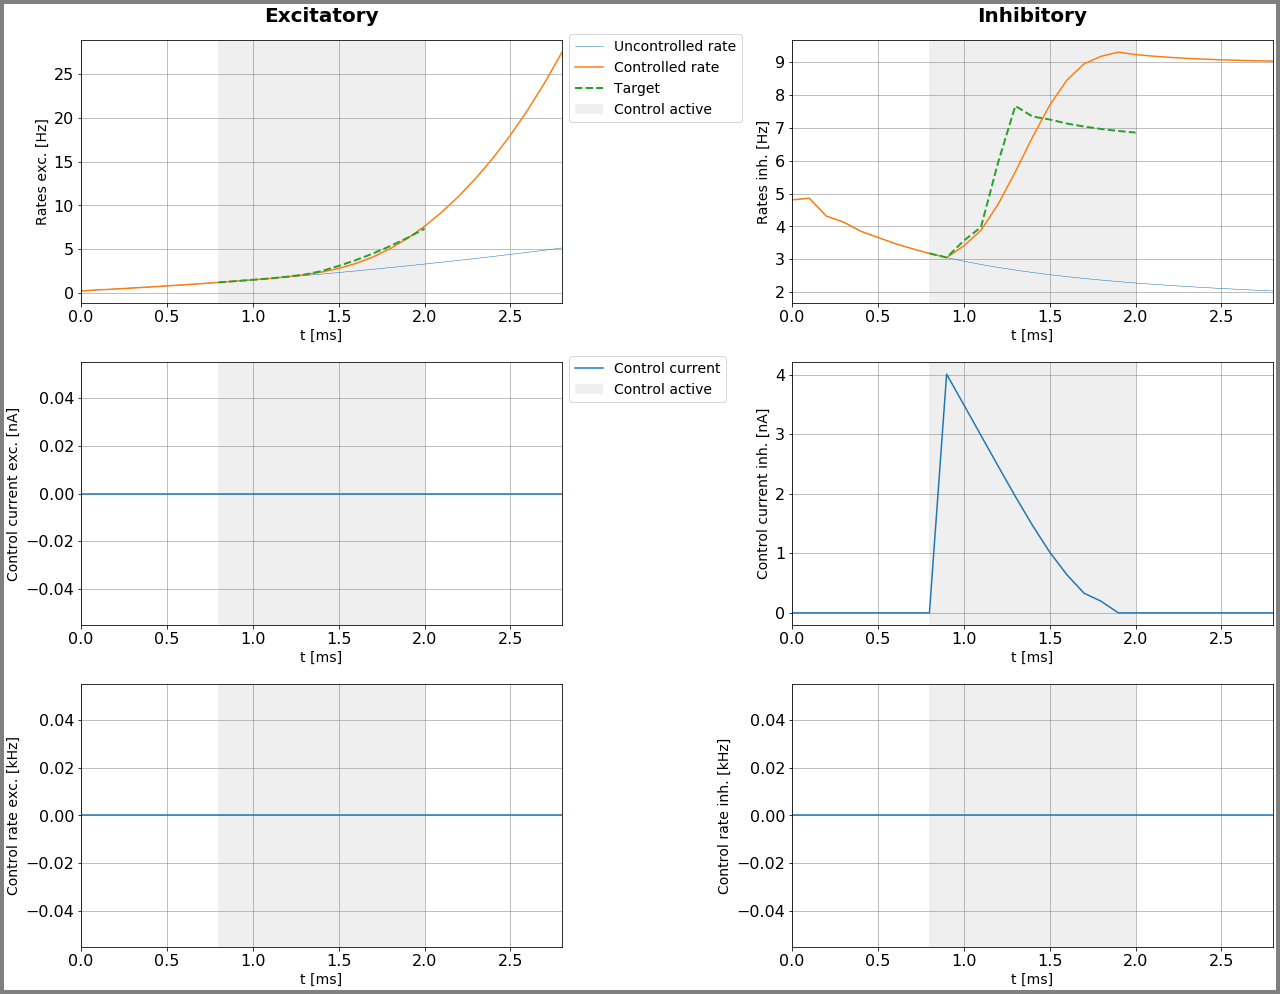

In [443]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

### Test cases

- [] precision only, c0-p0, no delay
- [] precision only, c0-p0, delay
- [] precision only, c0-p1, no delay
- [] precision only, c0-p1, delay
- [] precision only, c1-p1, no delay
- [] precision only, c1-p1, delay
- [] precision only, c1-p0, no delay
- [] precision only, c1-p0, delay
- [] precision only, c2-p0, no delay
- [] precision only, c2-p0, no delay
- [] precision only, c2-p1, delay
- [] precision only, c2-p1, delay

- [] p+e+s, c0-p0, no delay
- [] p+e+s, c0-p0, delay
- [] p+e+s, c0-p1, no delay
- [] p+e+s, c0-p1, delay
- [] p+e+s, c1-p1, no delay
- [] p+e+s, c1-p1, delay
- [] p+e+s, c1-p0, no delay
- [] p+e+s, c1-p0, delay
- [] p+e+s, c2-p0, no delay
- [] p+e+s, c2-p0, no delay
- [] p+e+s, c2-p1, delay
- [] p+e+s, c2-p1, delay

In [403]:
cost.setParams(costparams[0], costparams[1], costparams[2])
setinitvars(high_state_vars)
max_it = 100
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-6

aln.params.duration = dur
control3 = aln.getZeroControl()
#control4 = bestControlA_A2[:,:,n_pre-1:-n_pre+1]


print(max_cntrl, min_cntrl)

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control3, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

#0.003933378523157236

set cost params
5.0 -5.0
RUN  0 , total integrated cost:  0.09016048310234728
RUN  1 , total integrated cost:  0.003767931200038662
RUN  2 , total integrated cost:  0.0011590077898229003
RUN  3 , total integrated cost:  0.0005705772316226778
RUN  4 , total integrated cost:  0.0003182185579755777
RUN  5 , total integrated cost:  0.0002446601459334994
RUN  6 , total integrated cost:  0.00020232088894409802
RUN  7 , total integrated cost:  0.00017352313765918204
RUN  8 , total integrated cost:  0.00015444018998087564
RUN  9 , total integrated cost:  0.0001420899477144998
RUN  10 , total integrated cost:  0.00013382523437222146
RUN  11 , total integrated cost:  0.0001288135121417701
RUN  12 , total integrated cost:  0.0001238721417349031
RUN  13 , total integrated cost:  0.00012296577339541807
RUN  14 , total integrated cost:  0.00012235042051609928
RUN  15 , total integrated cost:  0.0001219769103557802
RUN  16 , total integrated cost:  0.0001213046722377883
RUN  17 , total integrated cos

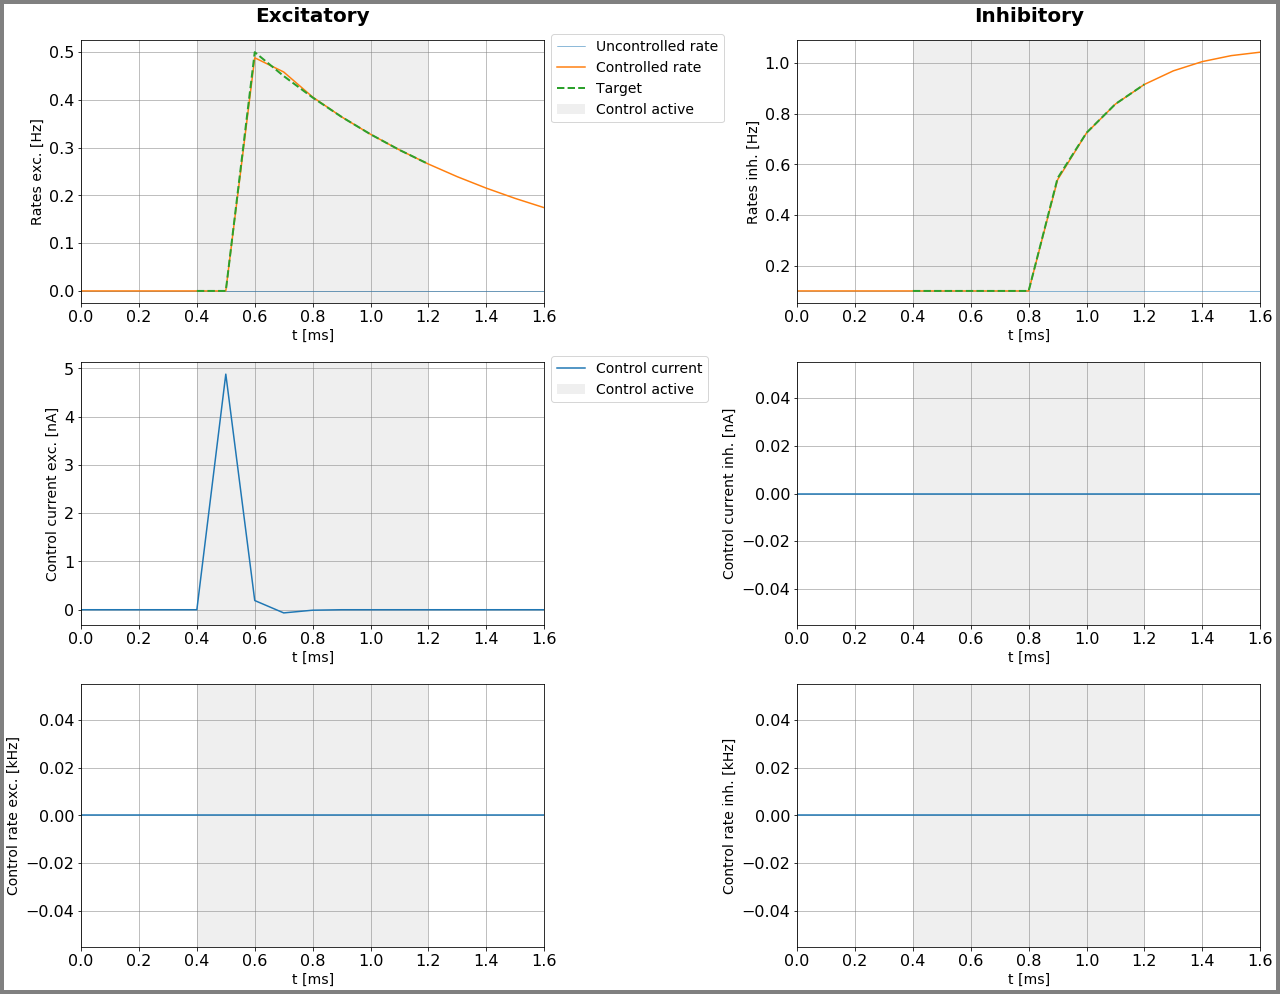

In [404]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

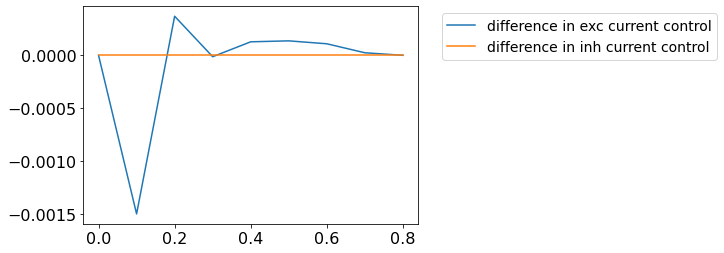

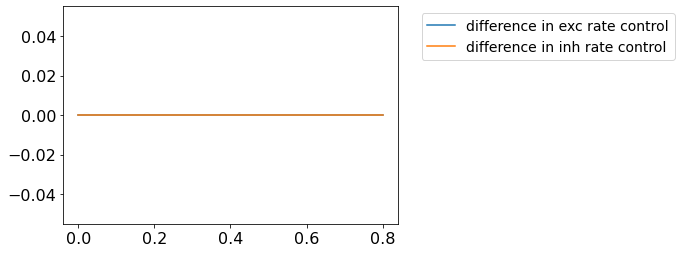

In [114]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

### Testcases

1. PRECISION ONLY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [x] 0 control, 1 precision measure, no delay
    - [x] 1 control, 0 precision measure, no delay
    - [] 2 control, 0 precision measure, no delay (slow to converge)
    - [] 2 control, 1 precision measure, no delay (slow to converge)

2. PRECISON + ENERGY + SPARSITY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [] 0 control, 1 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [x] 2 control, 0 precision measure, no delay
    - [] 2 control, 1 precision measure, no delay (requires different weights, zero control as output, gradient nonvanishing because on boundary. At higher weights, gradient vanishes)
    
3. PRECISION ONLY, DELAY
    - [x] 0 control, 0 precision measure, delay
    - [x] 1 control, 1 precision measure, delay
    - [] 0 control, 1 precision measure, delay (not in every case, could have several solutions)
    - [] 1 control, 0 precision measure, delay (not in every case, could have several solutions)
    - [x] 2 control, 0 precision measure, delay (sometimes slow convergence)
    - [x] 2 control, 1 precision measure, delay (sometimes slow to converge)

4. PRECISON + ENERGY + SPARSITY
    - [] 0 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 1 control, 1 precision measure, delay (gradient does not quite vanish)
    - [] 0 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 2 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 2 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    
The cost functional should always have more than one minimum. If the "direct" control (0,0; 1,1; 2,0; 3,1) is not applied, it is much more likely to end up in a local minimum, because there is no "dominant" contribution.